In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
planet_scaled = pd.read_csv(
    "../data/planet_scaled.csv"
)

#### trying to understand no of clusters needed 

In [9]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(planet_scaled)

    inertia.append(
        kmeans.inertia_
    )

print(inertia) #Elbow Method

[11675.668331532292, 7847.148049405785, 6256.589857312409, 5190.5135498169375, 4620.993072893683, 4196.570871500361, 3764.611013536511, 3342.519906592617, 3088.183365902401]


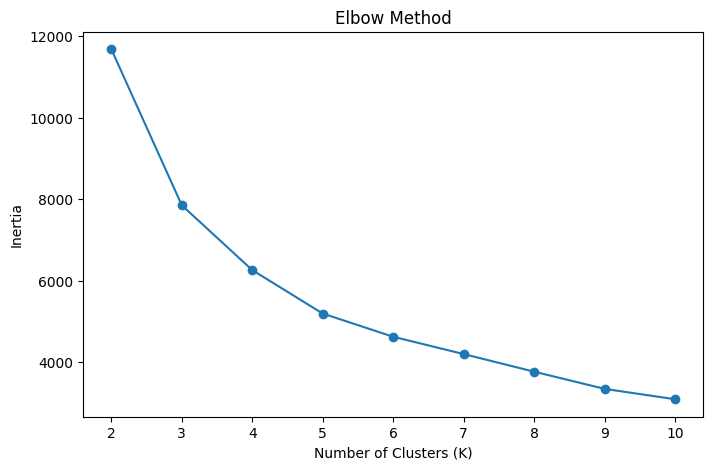

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

k=4 or k=5 most plausible value for k

In [11]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(
        planet_scaled
    )
    score = silhouette_score(
        planet_scaled,
        labels
    )
    silhouette_scores.append(score)

print(silhouette_scores)

[0.5124373624352369, 0.5167026478045886, 0.38503453489916006, 0.3879451180266569, 0.3879858619244323, 0.3355323292670912, 0.33692694822424923, 0.34829812968874346, 0.3392262096811254]


k=3 is most plausible 

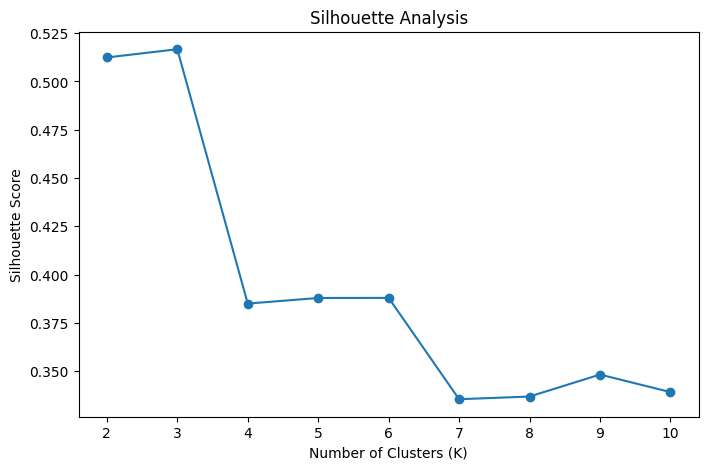

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

creating a clusting model for k-3

In [13]:
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_3 = kmeans_3.fit_predict(
    planet_scaled
)

clusters_3[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 1, 2], dtype=int32)

In [14]:
import pandas as pd

pd.Series(clusters_3).value_counts().sort_index()

0    3544
1    1461
2     728
Name: count, dtype: int64

In [15]:
centers = pd.DataFrame(
    kmeans_3.cluster_centers_,
    columns=planet_scaled.columns
)

centers

,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax
0,-0.709690,-0.668066,0.358870,-0.347677
1,1.089833,0.729865,-1.242488,-0.015387
2,1.267713,1.787490,0.746485,1.723418


#### cluster 0
- smaller than avg
- less mass than avg
- sligtly denser than avg
- closer to star than avg

#### cluster 1
- Large radius
- Large mass
- Very low density
- Average orbital distance

#### cluster 2
- large in size
- large mass - massive
- large density 
- farther from the sun

In [19]:
planet_scaled.head()

,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax
0,1.227724,2.189879,1.761822,1.130717
1,1.236438,2.170099,1.690449,1.281534
2,1.303699,1.583833,0.192650,0.889184
3,1.253655,1.961962,1.178377,1.638133
4,1.335804,1.297996,-0.537079,1.328576


In [23]:
%whos

Variable            Type         Data/Info
------------------------------------------
KMeans              ABCMeta      <class 'sklearn.cluster._kmeans.KMeans'>
StandardScaler      type         <class 'sklearn.preproces<...>ng._data.StandardScaler'>
centers             DataFrame    Shape: (3, 4)
clusters_3          ndarray      5733: 5733 elems, type `int32`, 22932 bytes
inertia             list         n=9
k                   int          10
kmeans              KMeans       KMeans(n_clusters=10, n_init=10, random_state=42)
kmeans_3            KMeans       KMeans(n_clusters=3, n_init=10, random_state=42)
labels              ndarray      5733: 5733 elems, type `int32`, 22932 bytes
np                  module       <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
pd                  module       <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
planet_scaled       DataFrame    Shape: (5733, 4)
plt                 module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.

In [24]:
df = pd.read_csv(
    "../data/PSCompPars.csv",
    comment="#"
)

df.shape

(6298, 320)

In [25]:
planet_features_core = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbsmax"
]

planet_drop = df[planet_features_core].dropna()

planet_drop.shape

(5733, 4)

In [27]:
# What is the average radius, mass, density, and orbital distance of the planets 
# in each discovered population?

clustered_df = planet_drop.copy()
clustered_df["cluster"] = clusters_3
clustered_df.groupby("cluster").mean()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax
cluster,,,,
0,2.155492,11.623982,5.381494,0.157428
1,11.661364,274.778771,0.777044,0.652537
2,12.803188,2561.060134,11.406877,123.675548


In [28]:
clustered_df.groupby("cluster").std()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax
cluster,,,,
0,0.838897,109.990116,28.093522,0.373808
1,4.800503,368.610931,0.662375,2.547997
2,1.802424,2097.771333,77.058396,981.903455


This suggests Cluster 2 may not be a clean planetary population."extreme objects" cluster

In [29]:
clustered_df.groupby("cluster")["pl_orbsmax"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,3544.0,0.157428,0.373808,0.005626,0.05100,0.087445,0.152725,10.26
1,1461.0,0.652537,2.547997,0.010200,0.04739,0.085400,0.569710,71.00
2,728.0,123.675548,981.903455,0.020400,1.29000,2.550000,5.750000,19000.00


clearly cluster 2 is extremely skewed. mean and median difference i shuge

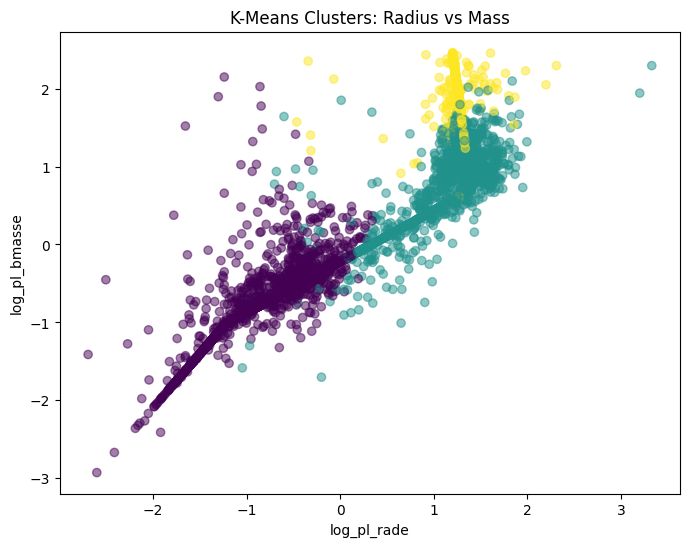

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    planet_scaled["log_pl_rade"],
    planet_scaled["log_pl_bmasse"],
    c=clusters_3,
    alpha=0.5
)

plt.xlabel("log_pl_rade")
plt.ylabel("log_pl_bmasse")
plt.title("K-Means Clusters: Radius vs Mass")

plt.show()

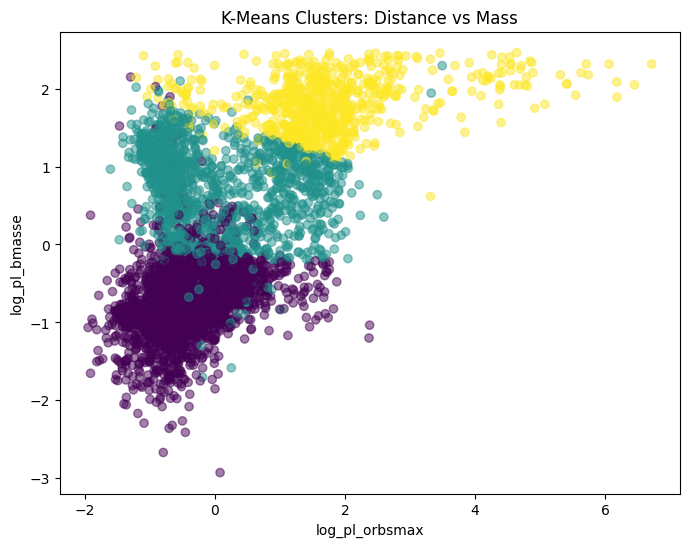

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    planet_scaled["log_pl_orbsmax"],
    planet_scaled["log_pl_bmasse"],
    c=clusters_3,
    alpha=0.5
)

plt.xlabel("log_pl_orbsmax")
plt.ylabel("log_pl_bmasse")
plt.title("K-Means Clusters: Distance vs Mass")

plt.show()

Cluster 0 - Small, dense planets.

Cluster 1 - Large, low-density planets.

Cluster 2 - Extremely massive giant planets.

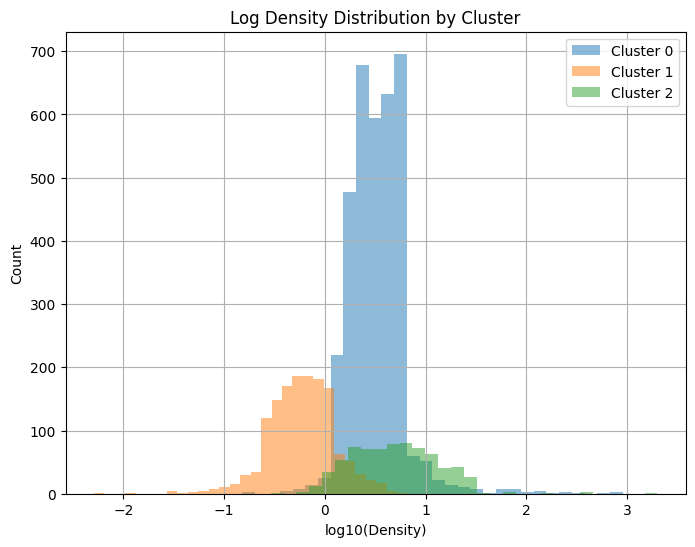

In [33]:
plt.figure(figsize=(8,6))

for cluster in sorted(clustered_df["cluster"].unique()):
    np.log10(
        clustered_df[
            clustered_df["cluster"] == cluster
        ]["pl_dens"]
    ).hist(
        bins=30,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel("log10(Density)")
plt.ylabel("Count")
plt.title("Log Density Distribution by Cluster")
plt.legend()

plt.show()

In [34]:
clustered_df.groupby("cluster").median()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax
cluster,,,,
0,2.10000,5.300000,3.18,0.087445
1,12.66617,183.387910,0.60,0.085400
2,12.80000,1875.192301,4.89,2.550000


In [35]:
clustered_df["cluster"].value_counts(normalize=True).sort_index() * 100

cluster
0    61.817548
1    25.484040
2    12.698413
Name: proportion, dtype: float64

#### analyzing cluster 2

In [36]:
clustered_df[clustered_df["cluster"] == 2].describe()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax,cluster
count,728.000000,728.000000,728.000000,728.000000,728.0
mean,12.803188,2561.060134,11.406877,123.675548,2.0
std,1.802424,2097.771333,77.058396,981.903455,0.0
min,2.500000,108.061658,0.290000,0.020400,2.0
25%,12.300000,949.035623,2.357500,1.290000,2.0
50%,12.800000,1875.192301,4.890000,2.550000,2.0
75%,13.200000,3468.938148,9.782500,5.750000,2.0
max,33.600000,9534.852210,2000.000000,19000.000000,2.0


The K=3 solution is supported by both the elbow method and silhouette analysis. The resulting clusters correspond to three physically interpretable planetary populations distinguished primarily by size, mass, and density.

## K=3 Cluster Summary


In [38]:
clustered_df.groupby("cluster").median().round(2)

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax
cluster,,,,
0,2.10,5.30,3.18,0.09
1,12.67,183.39,0.60,0.09
2,12.80,1875.19,4.89,2.55


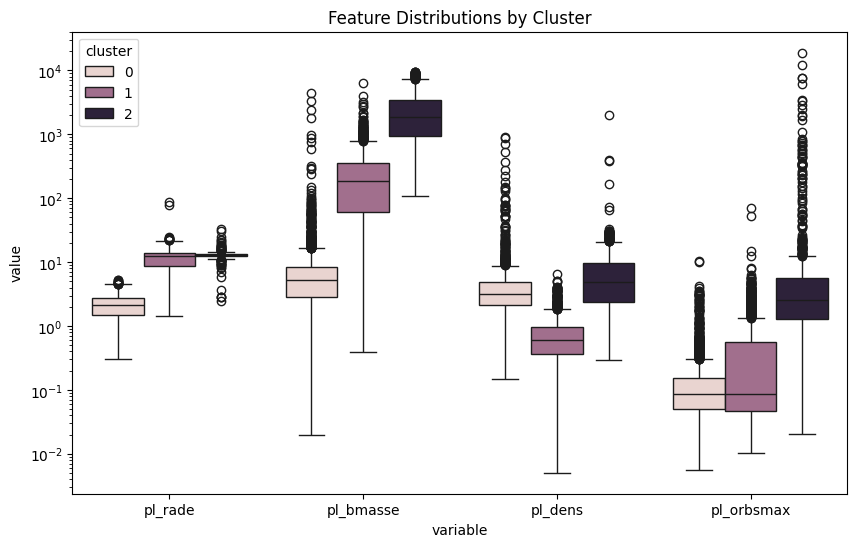

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=clustered_df.melt(
        id_vars="cluster",
        value_vars=[
            "pl_rade",
            "pl_bmasse",
            "pl_dens",
            "pl_orbsmax"
        ]
    ),
    x="variable",
    y="value",
    hue="cluster"
)

plt.yscale("log")
plt.title("Feature Distributions by Cluster")
plt.show()

### Dataset A Findings

K=3 clusters reveal:

- Small-to-medium dense planets
- Large low-density giant planets
- Large extremely massive higher-density giant planets

The separation is driven primarily by: densityy, mass, radius
with orbital distance playing a secondary role.

### median imputation

In [42]:
from sklearn.impute import SimpleImputer

planet_imputed = df[
    [
        "pl_rade",
        "pl_bmasse",
        "pl_dens",
        "pl_orbsmax"
    ]
].copy()

imputer = SimpleImputer(strategy="median")

planet_imputed[:] = imputer.fit_transform(planet_imputed)

planet_imputed.shape

(6298, 4)

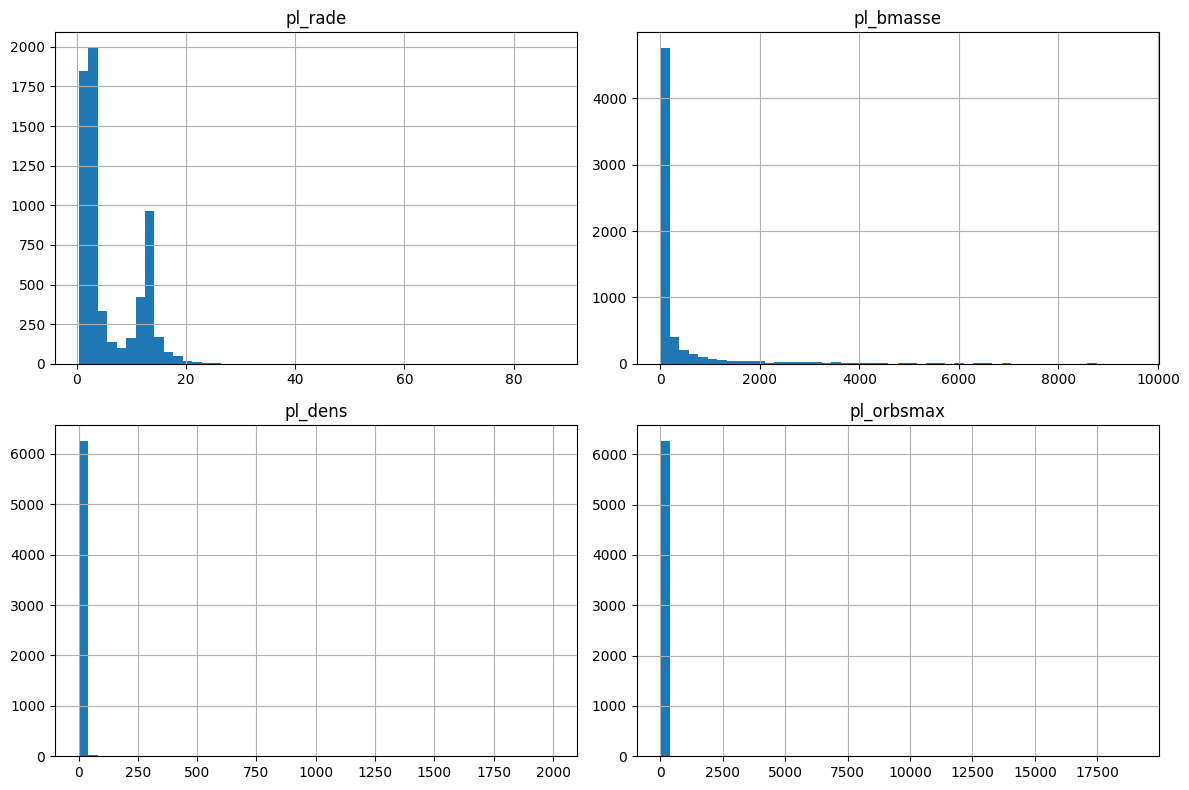

In [43]:
planet_imputed.hist(
    figsize=(12,8),
    bins=50
)

plt.tight_layout()
plt.show()

In [44]:
planet_imputed["log_pl_rade"] = np.log10(planet_imputed["pl_rade"])
planet_imputed["log_pl_bmasse"] = np.log10(planet_imputed["pl_bmasse"])
planet_imputed["log_pl_dens"] = np.log10(planet_imputed["pl_dens"])
planet_imputed["log_pl_orbsmax"] = np.log10(planet_imputed["pl_orbsmax"])

planet_imputed[
    [
        "log_pl_rade",
        "log_pl_bmasse",
        "log_pl_dens",
        "log_pl_orbsmax"
    ]
].describe()

,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax
count,6298.000000,6298.000000,6298.000000,6298.000000
mean,0.577496,1.373535,0.352701,-0.795838
std,0.401868,1.046399,0.453893,0.729205
min,-0.508919,-1.698970,-2.292430,-2.356547
25%,0.267172,0.634477,0.123852,-1.259637
50%,0.453318,0.963788,0.403121,-0.989997
75%,1.071134,2.256348,0.651035,-0.574629
max,1.940546,3.979314,3.301030,4.278754


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

planet_imputed_scaled = pd.DataFrame(
    scaler.fit_transform(
        planet_imputed[
            [
                "log_pl_rade",
                "log_pl_bmasse",
                "log_pl_dens",
                "log_pl_orbsmax"
            ]
        ]
    ),
    columns=[
        "log_pl_rade",
        "log_pl_bmasse",
        "log_pl_dens",
        "log_pl_orbsmax"
    ]
)

planet_imputed_scaled.describe()

,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax
count,6.298000e+03,6.298000e+03,6.298000e+03,6.298000e+03
mean,1.624613e-16,-1.624613e-16,2.030767e-16,-3.610252e-17
std,1.000079e+00,1.000079e+00,1.000079e+00,1.000079e+00
min,-2.703624e+00,-2.936499e+00,-5.828123e+00,-2.140458e+00
25%,-7.722642e-01,-7.063428e-01,-5.042340e-01,-6.360847e-01
50%,-3.090243e-01,-3.916093e-01,1.110903e-01,-2.662825e-01
75%,1.228457e+00,8.437355e-01,6.573309e-01,3.033804e-01
max,3.392053e+00,2.490433e+00,6.496169e+00,6.959624e+00


In [46]:
inertia_b = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(planet_imputed_scaled)

    inertia_b.append(kmeans.inertia_)

inertia_b

[13175.738468207235,
 9021.452351808635,
 7244.675975125758,
 6108.048987194294,
 5377.794261380734,
 4890.835986451603,
 4419.629455205699,
 3967.2579351526947,
 3672.314769570443]

In [47]:
from sklearn.metrics import silhouette_score

silhouette_scores_b = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(planet_imputed_scaled)

    score = silhouette_score(
        planet_imputed_scaled,
        labels
    )

    silhouette_scores_b.append(score)

silhouette_scores_b

[0.5048626240040519,
 0.5061007625394591,
 0.37706379617920377,
 0.37879514495829086,
 0.38235799845556545,
 0.3845168831365229,
 0.3368429872743501,
 0.34565144694807426,
 0.34859523879538523]

### **Clustering Summary**

Using four planetary properties:

- Planet Radius (`pl_rade`)
- Planet Mass (`pl_bmasse`)
- Planet Density (`pl_dens`)
- Orbital Distance (`pl_orbsmax`)

K-Means clustering was performed on both:

- Dataset A (5733 planets, missing values dropped)
- Dataset B (6298 planets, median imputation)

Both datasets independently identified **K=3 as the optimal clustering solution**, supported by the elbow method and the highest silhouette scores.

The discovered planetary populations were consistent across both datasets:

1. **Small, moderately dense planets**
   - Radius ≈ 2 Earth radii
   - Mass ≈ 5 Earth masses
   - Likely rocky / super-Earth type worlds

2. **Large, low-density giant planets**
   - Radius ≈ 13 Earth radii
   - Low density
   - Puffy gas giant population

3. **Massive, higher-density giant planets**
   - Similar radius to Cluster 2
   - Much greater mass
   - Higher density and more compact structure

Analysis of cluster centroids, distributions, and visualizations showed that **density and mass were the strongest drivers of cluster separation**, while orbital distance played a secondary role.

The agreement between Dataset A and Dataset B suggests that the three-cluster structure is robust and not an artifact of missing-value handling.

### exploratory investigation - with k=4 because cluster 2 looked suspicious

hypothesis - The massive giant-planet cluster (Cluster 2) may contain multiple planetary populations.

In [49]:
kmeans_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters_4 = kmeans_4.fit_predict(
    planet_imputed_scaled
)

pd.Series(clusters_4).value_counts().sort_index()

0    1383
1    1713
2     769
3    2433
Name: count, dtype: int64

Now K=4 has redistributed that structure much more evenly.

In [50]:
centers_4 = pd.DataFrame(
    kmeans_4.cluster_centers_,
    columns=planet_imputed_scaled.columns
)

centers_4

,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax
0,1.214919,0.841597,-1.303277,-0.039956
1,-1.096588,-0.911172,0.830573,-0.618566
2,1.273620,1.804304,0.720104,1.771916
3,-0.321081,-0.407151,-0.071558,-0.101825


In [51]:
clustered_df_4 = planet_imputed.copy()

clustered_df_4["cluster"] = clusters_4

clustered_df_4.groupby("cluster").median()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax
cluster,,,,,,,,
0,13.136925,206.588465,0.563,0.0813,1.118494,2.315106,-0.249492,-1.089909
1,1.420000,2.730000,4.990,0.0588,0.152288,0.436163,0.698101,-1.230623
2,12.800000,1875.197000,4.610,2.5040,1.107210,3.273047,0.663701,0.398634
3,2.690000,7.900000,2.230,0.1126,0.429752,0.897627,0.348305,-0.948462


Radius Gap

which separates rocky planets from planets with substantial gaseous envelopes.

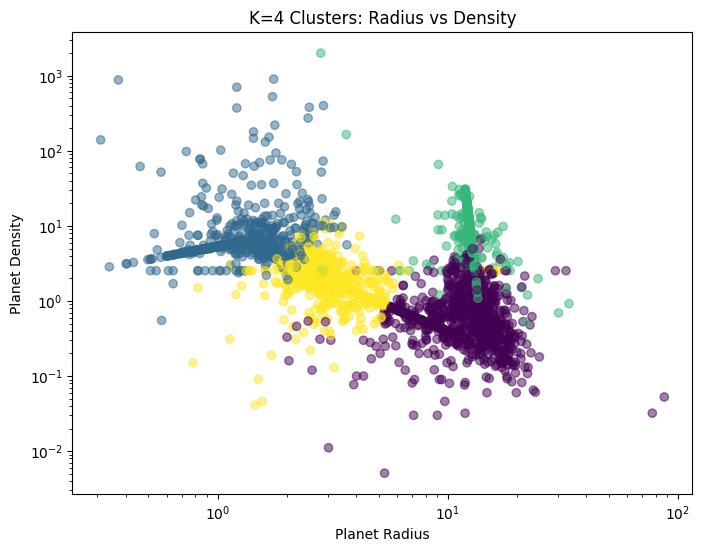

In [53]:
plt.figure(figsize=(8,6))

plt.scatter(
    clustered_df_4["pl_rade"],
    clustered_df_4["pl_dens"],
    c=clusters_4,
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Planet Radius")
plt.ylabel("Planet Density")
plt.title("K=4 Clusters: Radius vs Density")

plt.show()

did k=4 discover the radius gap? 

In [54]:
clustered_df_4.groupby("cluster")["pl_rade"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,1383.0,12.334138,4.496239,2.000000,9.976005,13.136925,14.10,87.20587
1,1713.0,1.429576,0.404885,0.309800,1.170000,1.420000,1.68,3.64000
2,769.0,12.584793,2.251693,2.802245,12.300000,12.800000,13.20,33.60000
3,2433.0,2.960538,1.255572,0.780000,2.318982,2.690000,3.24,16.56000


1.7 → 2.3 Earth radii

That's almost exactly where exoplanet scientists talk about the Radius Gap / Fulton Gap.

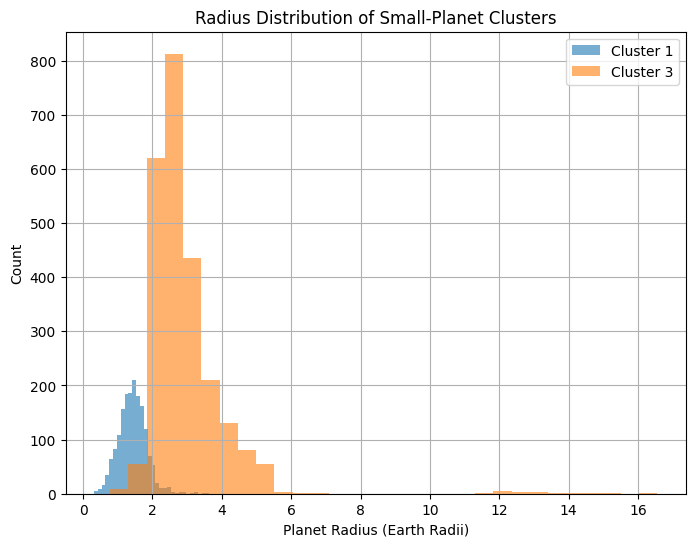

In [55]:
plt.figure(figsize=(8,6))

clustered_df_4[clustered_df_4["cluster"] == 1]["pl_rade"].hist(
    bins=30,
    alpha=0.6,
    label="Cluster 1"
)

clustered_df_4[clustered_df_4["cluster"] == 3]["pl_rade"].hist(
    bins=30,
    alpha=0.6,
    label="Cluster 3"
)

plt.xlabel("Planet Radius (Earth Radii)")
plt.ylabel("Count")
plt.title("Radius Distribution of Small-Planet Clusters")
plt.legend()

plt.show()

Strong Result

K=3 is the statistically preferred clustering solution.

It is:

reproduced in Dataset A
reproduced in Dataset B
supported by silhouette analysis
Interesting Secondary Result

K=4 consistently subdivides the small-planet population into two physically distinct radius regimes:

Population	Median Radius
Cluster 1	1.42 R⊕
Cluster 3	2.69 R⊕

These values are remarkably close to the known transition between:

rocky planets
super-Earth / mini-Neptune planets

## VALIDATION PHASE

### hypothests 2- K-Means independently rediscovered the Radius Gap.

In [56]:
small_clusters = clustered_df_4[
    clustered_df_4["cluster"].isin([1, 3])
]

small_clusters.groupby("cluster").agg({
    "pl_rade": ["median", "mean"],
    "pl_bmasse": ["median", "mean"],
    "pl_dens": ["median", "mean"],
    "pl_orbsmax": ["median", "mean"]
}).round(2)

pl_rade       pl_bmasse        pl_dens       pl_orbsmax      
         median  mean    median   mean  median  mean     median  mean
cluster                                                              
1          1.42  1.43      2.73  13.60    4.99  9.27       0.06  0.07
3          2.69  2.96      7.90  23.78    2.23  2.27       0.11  0.24

Cluster 1 - Small + dense

Cluster 3- Larger + less dense


The K=4 solution subdivides the K=3 small-planet population into two physically distinct groups. The first consists of compact, high-density planets consistent with rocky worlds, while the second contains larger, lower-density planets consistent with super-Earth or mini-Neptune type planets. The separation occurs near the known exoplanet radius-gap regime and is accompanied by systematic changes in both mass and density.

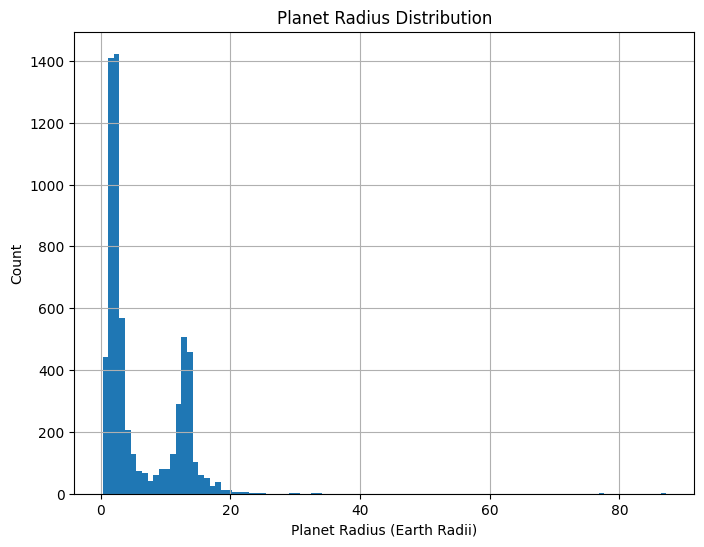

In [57]:
plt.figure(figsize=(8,6))

planet_imputed["pl_rade"].hist(
    bins=100
)

plt.xlabel("Planet Radius (Earth Radii)")
plt.ylabel("Count")
plt.title("Planet Radius Distribution")

plt.show()

we still considet k=4 as a hypothesis cause statistics supports k=3. so lets check is k=4 is stable

In [58]:
for seed in [0, 7, 21, 99]:
    kmeans_test = KMeans(
        n_clusters=4,
        random_state=seed,
        n_init=10
    )

    labels = kmeans_test.fit_predict(
        planet_imputed_scaled
    )

    centers = pd.DataFrame(
        kmeans_test.cluster_centers_,
        columns=planet_imputed_scaled.columns
    )

    print(f"\nSeed = {seed}")
    print(centers[["log_pl_rade", "log_pl_bmasse", "log_pl_dens"]])


Seed = 0
   log_pl_rade  log_pl_bmasse  log_pl_dens
0    -0.321081      -0.407151    -0.071558
1     1.273620       1.804304     0.720104
2    -1.096588      -0.911172     0.830573
3     1.214919       0.841597    -1.303277

Seed = 7
   log_pl_rade  log_pl_bmasse  log_pl_dens
0     1.273742       1.803707     0.718560
1    -0.321081      -0.407151    -0.071558
2     1.214808       0.841232    -1.303880
3    -1.096588      -0.911172     0.830573

Seed = 21
   log_pl_rade  log_pl_bmasse  log_pl_dens
0     1.273620       1.804304     0.720104
1    -0.321081      -0.407151    -0.071558
2     1.214919       0.841597    -1.303277
3    -1.096588      -0.911172     0.830573

Seed = 99
   log_pl_rade  log_pl_bmasse  log_pl_dens
0    -0.321081      -0.407151    -0.071558
1     1.273620       1.804304     0.720104
2    -1.096588      -0.911172     0.830573
3     1.214919       0.841597    -1.303277


K=4 is not a random initialization artifact.
The algorithm repeatedly finds the same four population

K = 4 provides the most meaningful planetary taxonomy.
Supported by:

Stable across random seeds
Physically interpretable populations
Consistent changes in radius, mass, and density
Subdivision of small planets occurs near the known exoplanet radius-gap regime
Giant-planet populations remain stable

## Clustering Conclusion

Exoplanets were clustered using K-Means on four planetary properties:

- Planet Radius (`pl_rade`)
- Planet Mass (`pl_bmasse`)
- Planet Density (`pl_dens`)
- Orbital Distance (`pl_orbsmax`)

Two datasets were evaluated:

1. Dataset A (5733 planets, missing values removed)
2. Dataset B (6298 planets, median imputation)

Elbow and silhouette analyses consistently identified K=3 as the statistically optimal clustering solution. The K=3 model revealed three robust planetary populations consisting of small planets, low-density giant planets, and massive giant planets.

To further investigate the structure of the small-planet population, a K=4 sensitivity analysis was performed. Although K=4 produced a lower silhouette score, the resulting clusters were highly stable across multiple random initializations and remained physically interpretable.

The K=4 solution subdivided the small-planet population into two distinct groups:

- Compact, high-density rocky planets
- Larger, lower-density super-Earth / mini-Neptune planets

This separation occurred near the known exoplanet radius-gap regime and was accompanied by systematic differences in planetary mass and density.

The final K=4 taxonomy consists of:

1. Rocky Planets
2. Super-Earth / Mini-Neptunes
3. Puffy Gas Giants
4. Massive Compact Giants

Given the physical interpretability, stability, and consistency with established exoplanet science, the K=4 solution was selected as the planetary classification framework for the remainder of the Celestia project.

In [59]:
planet_imputed["planet_class"] = clusters_4
planet_imputed.head()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax,planet_class
0,12.2,4914.898486,14.90,1.178,1.086360,3.691515,1.173186,0.071145,2
1,12.3,4684.814200,13.80,1.530,1.089905,3.670692,1.139879,0.184691,2
2,13.1,1131.151301,2.76,0.775,1.117271,3.053521,0.440909,-0.110698,2
3,12.5,2828.672822,7.96,2.839,1.096910,3.451583,0.900913,0.453165,2
4,13.5,565.737400,1.26,1.660,1.130334,2.752615,0.100371,0.220108,2


In [60]:
clusters_4.shape

(6298,)

### running k=4 on dataset A (more scientifically pure)

In [63]:
kmeans_4_A = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters_4_A = kmeans_4_A.fit_predict(
    planet_scaled
)

centers_4_A = pd.DataFrame(
    kmeans_4_A.cluster_centers_,
    columns=planet_scaled.columns
)

centers_4_A

,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax
0,1.193086,0.825635,-1.287575,-0.040366
1,-1.097334,-0.914167,0.823376,-0.643164
2,1.275037,1.784623,0.720238,1.734436
3,-0.354950,-0.441033,-0.069987,-0.090518


## CONCLUSION

datset A and B difference

| Population Type            | Δ Radius | Δ Mass | Δ Density | Δ Distance |
| -------------------------- | -------: | -----: | --------: | ---------: |
| Puffy Giant                |   +0.022 | +0.016 |    -0.015 |     +0.000 |
| Rocky                      |   +0.000 | +0.003 |    +0.008 |     +0.024 |
| Massive Giant              |   -0.001 | +0.019 |    -0.000 |     +0.038 |
| Super-Earth / Mini-Neptune |   +0.034 | +0.034 |    -0.002 |     -0.011 |


The K=4 clustering structure was highly robust to missing-value treatment. Repeating the clustering analysis using a median-imputed dataset (6298 planets) produced centroid locations nearly identical to those obtained using the complete-case dataset (5733 planets). All four planetary populations—rocky planets, super-Earth/mini-Neptunes, puffy gas giants, and massive compact giants—were recovered with minimal centroid drift.

- Cluster centroids barely moved.
- Cluster interpretations remained unchanged.
- K=3 and K=4 conclusions remained unchanged.

recoverd 565 planets nearly 10% in the process

The median-imputed dataset (6298 planets) was selected as the final analysis dataset. Comparison against the complete-case dataset (5733 planets) showed that cluster centroids, population structure, and physical interpretations remained nearly unchanged after imputation. Therefore, the additional 565 planets were retained, increasing sample size while preserving the scientific validity of the discovered planetary populations.

In [64]:
planet_imputed["planet_class"] = clusters_4

In [65]:
planet_imputed.head()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax,planet_class
0,12.2,4914.898486,14.90,1.178,1.086360,3.691515,1.173186,0.071145,2
1,12.3,4684.814200,13.80,1.530,1.089905,3.670692,1.139879,0.184691,2
2,13.1,1131.151301,2.76,0.775,1.117271,3.053521,0.440909,-0.110698,2
3,12.5,2828.672822,7.96,2.839,1.096910,3.451583,0.900913,0.453165,2
4,13.5,565.737400,1.26,1.660,1.130334,2.752615,0.100371,0.220108,2


## K=4 Cluster Evidence Table

| Cluster | Radius (R⊕) | Mass (M⊕) | Density | Distance (AU) | Evidence Summary |
|----------|------------|-----------|----------|--------------|------------------|
| 1 | 1.42 | 2.73 | 4.99 | 0.06 | Small radius, low mass, high density |
| 3 | 2.69 | 7.90 | 2.23 | 0.11 | Larger radius, higher mass, lower density |
| 0 | 13.14 | 206.59 | 0.56 | 0.08 | Very large radius, giant mass, extremely low density |
| 2 | 12.80 | 1875.20 | 4.61 | 2.50 | Giant radius, extremely high mass, much higher density |

In [66]:
class_map = {
    1: "Small Dense Planets",
    3: "Intermediate Low-Density Planets",
    0: "Low-Density Giants",
    2: "Massive Dense Giants"
}

In [67]:
planet_imputed["planet_class_name"] = (
    planet_imputed["planet_class"]
    .map(class_map)
)

In [68]:
planet_imputed["planet_class_name"].value_counts()

planet_class_name
Intermediate Low-Density Planets    2433
Small Dense Planets                 1713
Low-Density Giants                  1383
Massive Dense Giants                 769
Name: count, dtype: int64

## Final Planetary Taxonomy

K-Means clustering with K=4 identified four stable planetary populations:

| Population | Count |
|------------|-------:|
| Intermediate Low-Density Planets | 2433 |
| Small Dense Planets | 1713 |
| Low-Density Giants | 1383 |
| Massive Dense Giants | 769 |

The taxonomy was selected after evaluating:
- K=3 and K=4 solutions
- Complete-case and median-imputed datasets
- Cluster stability across random initializations

The final K=4 solution was retained because it revealed an additional stable subdivision within the small-planet population while preserving physically interpretable giant-planet populations.

In [69]:
planet_imputed.groupby(
    "planet_class_name"
)[
    [
        "pl_rade",
        "pl_bmasse",
        "pl_dens",
        "pl_orbsmax"
    ]
].median()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax
planet_class_name,,,,
Intermediate Low-Density Planets,2.690000,7.900000,2.230,0.1126
Low-Density Giants,13.136925,206.588465,0.563,0.0813
Massive Dense Giants,12.800000,1875.197000,4.610,2.5040
Small Dense Planets,1.420000,2.730000,4.990,0.0588


In [72]:
planet_imputed.to_csv(
    "../data/processed/planet_classes.csv",
    index=False
)

# Clustering Phase Complete

Final Dataset:
- 6298 planets
- Median-imputed dataset
- Four discovered planetary populations

Final Planet Taxonomy:
1. Small Dense Planets
2. Intermediate Low-Density Planets
3. Low-Density Giants
4. Massive Dense Giants

Output:
data/processed/planet_classes.csv

This dataset will serve as the input for the classification phase.

In [74]:
type(kmeans_4)

sklearn.cluster._kmeans.KMeans

In [75]:
type(scaler)

sklearn.preprocessing._data.StandardScaler

In [76]:
import joblib

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

joblib.dump(
    kmeans_4,
    "../models/kmeans_k4.pkl"
)

['../models/kmeans_k4.pkl']

### Clustering Phase Summary

Dataset:
- Final dataset: Median-imputed dataset
- Number of planets: 6298

Features Used:
- Planet Radius (pl_rade)
- Planet Mass (pl_bmasse)
- Planet Density (pl_dens)
- Orbital Distance (pl_orbsmax)

Method:
- Log transformation
- StandardScaler
- K-Means clustering

Key Findings:
- K=3 was statistically optimal based on silhouette score.
- K=4 revealed an additional stable subdivision within the small-planet population.
- The K=4 solution was stable across:
  - Dataset A (drop missing values)
  - Dataset B (median imputation)
  - Multiple random initializations

Final Planet Taxonomy:
1. Small Dense Planets
2. Intermediate Low-Density Planets
3. Low-Density Giants
4. Massive Dense Giants

Saved Artifacts:
- data/processed/planet_classes.csv
- models/scaler.pkl
- models/kmeans_k4.pkl